In [1]:
# Reproducibility

import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [2]:
#Load the dataset

import pandas as pd
from pathlib import Path

# Set project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "annotated_data" / "final_annotated_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (2000, 14)


,text,topic,sentiment,annotator,confidence,match_key,match_text,source,date,channel,product,language,clean_text,match_score
0,i am writing to seek urgent assistance regardi...,Mobile Banking App,negative,annotator_1,high,i am writing to seek urgent assistance regardi...,i am writing to seek urgent assistance regardi...,CRM Tool,04/11/2025 00:00,Service Email,Mobile,english,i am writing to seek urgent assistance regardi...,99.737877
1,name seem to neglect your duty to give the bes...,Mobile Banking App,negative,annotator_1,high,name seem to neglect your duty to give the bes...,name seem to neglect your duty to give the bes...,CRM Tool,05/11/2025 00:00,Service Email,Mobile,english,seem to neglect your duty to give the best bec...,98.245614
2,namere seeking your assistance in providing ...,Payments,negative,annotator_1,high,namere seeking your assistance in providing a ...,namere seeking your assistance in providing a ...,CRM Tool,05/12/2025 00:00,Service Email,Thunes,english,namere seeking your assistance in providing a ...,88.442623
3,reminder on resolving this issue of payment ...,Acccount Issues,negative,annotator_1,high,reminder on resolving this issue of payment on...,reminder on resolving this issue of payment on...,CRM Tool,19/11/2025 00:00,Service Email,Card Online Disputes,english,name name reminder on resolving this issue of ...,97.071130
4,a member of you service and am trying to open...,Mobile Banking App,negative,annotator_1,high,a member of you service and am trying to open ...,a member of you service and am trying to open ...,CRM Tool,25/11/2025 00:00,Service Email,Mobile,english,namename a member of you service and am trying...,97.352342


In [3]:
# Select relevant features

X = df["clean_text"]
y = df["sentiment"]

print("Unique Sentiments:")
print(y.unique())

Unique Sentiments:
<StringArray>
['negative', 'neutral', 'positive']
Length: 3, dtype: str


In [4]:
# TF-IDF Feature Engineering

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.8
)

X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

In [5]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

In [6]:
# Train the SVM model

from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=SEED)

svm_model.fit(X_train, y_train)

print("SVM model trained successfully")

SVM model trained successfully


In [7]:
# Evaluate the model

from sklearn.metrics import classification_report, accuracy_score

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8575

Classification Report:

              precision    recall  f1-score   support

    negative       0.83      0.91      0.87       201
     neutral       0.88      0.79      0.83       161
    positive       0.92      0.89      0.91        38

    accuracy                           0.86       400
   macro avg       0.88      0.86      0.87       400
weighted avg       0.86      0.86      0.86       400



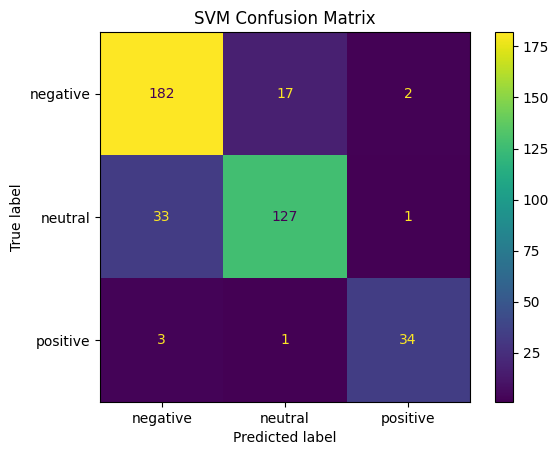

In [8]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

disp.plot()

plt.title("SVM Confusion Matrix")
plt.show()

In [9]:
# Save the model

import pickle

MODEL_PATH = PROJECT_ROOT / "models" / "svm_baseline_model.pkl"


MODEL_PATH.parent.mkdir(exist_ok=True)

with open(MODEL_PATH, "wb") as f:
    pickle.dump(svm_model, f)

print("SVM model saved")

SVM model saved


In [10]:
# Save the results

results = pd.DataFrame({
    "text": X_test,
    "Actual": y_test,
    "Predicted": y_pred
})

OUTPUT_PATH = PROJECT_ROOT / "results"

OUTPUT_PATH.mkdir(exist_ok=True)

results.to_csv(
    OUTPUT_PATH / "svm_baseline_results.csv",
    index=False
)

print("Results saved")

Results saved
